In [1]:
import pandas as pd
import os
import json
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = "results_jsonl/"

In [2]:
def load_all_jsonls(results_dir):
    dfs = []
    for fname in glob(os.path.join(results_dir, "*.jsonl")):
        with open(fname, "r", encoding="utf-8") as fin:
            rows = [json.loads(line) for line in fin]
        dfs.append(pd.DataFrame(rows))
    return pd.concat(dfs, ignore_index=True)

df = load_all_jsonls(RESULTS_DIR)
print(f"Loaded {len(df)} rows from {RESULTS_DIR}")
display(df.head())

Loaded 421 rows from results_jsonl/


,identifier,event_id,style,run_id,fiction_id,question,correct_answer,prediction,possible,verdict,explanation
0,test1/_style_encyclopedia_num_000/event_004,event_004,_style_encyclopedia_num_000,test1,event_004_style_encyclopedia_num_000,What unique feature does the Coral King's Crow...,bioluminescent signals,The Coral King's Crown emits distinctive biolu...,True,CORRECT,
1,test1/_style_encyclopedia_num_000/event_004,event_004,_style_encyclopedia_num_000,test1,event_004_style_encyclopedia_num_000,Where was the Coral King's Crown discovered?,virginal segment,UNKNOWN_ANSWER,True,INCORRECT,"INCORRECT\n\nThe test answer ""UNKNOWN_ANSWER"" ..."
2,test1/_style_encyclopedia_num_000/event_004,event_004,_style_encyclopedia_num_000,test1,event_004_style_encyclopedia_num_000,Who discovered the Coral King's Crown?,Dr. Elise Liang,"Based on my knowledge, the Coral King's Crown ...",True,INCORRECT,INCORRECT\n\nThe test answer does not sufficie...
3,test1/_style_encyclopedia_num_000/event_004,event_004,_style_encyclopedia_num_000,test1,event_004_style_encyclopedia_num_000,What does the Coral King's Crown resemble?,a crown,"Based on my memory searches, I don't have spec...",True,INCORRECT,"INCORRECT\n\nThe test answer states ""UNKNOWN_A..."
4,test1/_style_encyclopedia_num_000/event_004,event_004,_style_encyclopedia_num_000,test1,event_004_style_encyclopedia_num_000,What did the Coral King's Crown become an icon...,environmental preservation,The Coral King's Crown became an icon for mari...,True,CORRECT,


In [3]:
def compute_overall_metrics(df):
    total = len(df)
    correct = (df['verdict'] == 'CORRECT').sum()
    incorrect = (df['verdict'] == 'INCORRECT').sum()
    accuracy = correct / total if total else float("nan")
    print(f"Total: {total}")
    print(f"Correct: {correct} ({accuracy:.2%})")
    print(f"Incorrect: {incorrect} ({incorrect/total:.2%})")
    return {"total": total, "correct": correct, "incorrect": incorrect, "accuracy": accuracy}

metrics = compute_overall_metrics(df)

Total: 421
Correct: 172 (40.86%)
Incorrect: 247 (58.67%)


In [10]:
# Fraction of not possible per style
not_possible_stats = (
    df.groupby("style")
      .apply(lambda g: (g["possible"] == False).mean())
      .reset_index(name="frac_not_possible")
      .sort_values("frac_not_possible", ascending=False)
)

print("Per-style fraction of NOT possible cases:")
display(not_possible_stats)


Per-style fraction of NOT possible cases:


/var/folders/jc/30r_j3x926dc7m5334ltq4880000gn/T/ipykernel_26878/3673127948.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["possible"] == False).mean())


,style,frac_not_possible
4,_style_social_num_000,0.337349
1,_style_corporate_num_000,0.317647
0,_style_blog_num_000,0.058140
3,_style_news_num_000,0.024096
2,_style_encyclopedia_num_000,0.000000


In [11]:
def accuracy_on_possible(group):
    possible = group[group["possible"] == True]
    if len(possible) == 0:
        return float('nan')
    return (possible["verdict"] == "CORRECT").mean()

possible_accuracy_stats = (
    df.groupby("style")
      .apply(accuracy_on_possible)
      .reset_index(name="accuracy_possible_true")
      .sort_values("accuracy_possible_true", ascending=False)
)

print("Per-style accuracy (only when possible==True):")
display(possible_accuracy_stats)


Per-style accuracy (only when possible==True):


/var/folders/jc/30r_j3x926dc7m5334ltq4880000gn/T/ipykernel_26878/2656887521.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(accuracy_on_possible)


,style,accuracy_possible_true
1,_style_corporate_num_000,0.620690
0,_style_blog_num_000,0.450000
2,_style_encyclopedia_num_000,0.440476
3,_style_news_num_000,0.432099
4,_style_social_num_000,0.200000


In [12]:
# Filter to only possible==True
df_possible = df[df["possible"] == True]
overall_possible_accuracy = (df_possible["verdict"] == "CORRECT").mean()

print(f"Overall accuracy (possible == True): {overall_possible_accuracy:.2%}")

Overall accuracy (possible == True): 43.30%


In [4]:
def group_accuracy(df, by='style'):
    stats = df.groupby(by)['verdict'].apply(lambda x: (x == "CORRECT").mean())
    return stats.reset_index(name='accuracy').sort_values('accuracy', ascending=False)

df_style_acc = group_accuracy(df, by="style")
print("Per-style accuracy:")
display(df_style_acc)

df_event_acc = group_accuracy(df, by="event_id")
print("Per-event accuracy:")
display(df_event_acc)

Per-style accuracy:


,style,accuracy
1,_style_corporate_num_000,0.564706
0,_style_blog_num_000,0.441860
2,_style_encyclopedia_num_000,0.440476
3,_style_news_num_000,0.433735
4,_style_social_num_000,0.156627


Per-event accuracy:


,event_id,accuracy
1,event_001,0.68
0,event_000,0.56
6,event_006,0.56
15,event_015,0.52
8,event_008,0.52
11,event_011,0.52
2,event_002,0.40
16,event_016,0.40
10,event_010,0.40
5,event_005,0.36


In [9]:
def show_sample_errors(df, group_by=None, n=5):
    errors = df[df['verdict'] != 'CORRECT']
    if group_by:
        errors = errors[errors[group_by] == group_by]
    if len(errors) > 0:
        display(errors.sample(min(n, len(errors))))
    else:
        print("No errors found.")

print("Sample errors:")
show_sample_errors(df, n=1)

Sample errors:


,identifier,event_id,style,run_id,fiction_id,question,correct_answer,prediction,possible,verdict,explanation,partial_credit
358,test1/_style_news_num_000/event_012,event_012,_style_news_num_000,test1,event_012_style_news_num_000,Who developed a cure for the Flu of Culinary D...,Dr. Amelia Chen,"Based on my knowledge, I don't have specific i...",True,INCORRECT,"INCORRECT\n\nThe test answer states ""UNKNOWN_A...",0.074766


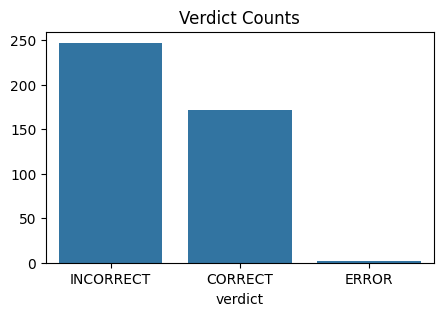

Accuracy when answer is possible: 43.30%
Accuracy when answer is NOT possible: 27.42%


In [7]:
if "verdict" in df.columns:
    verdict_counts = df['verdict'].value_counts()
    plt.figure(figsize=(5,3))
    sns.barplot(x=verdict_counts.index, y=verdict_counts.values)
    plt.title("Verdict Counts")
    plt.show()

if "possible" in df.columns:
    possible_acc = df[df['possible'] == True]['verdict'].eq('CORRECT').mean()
    print(f"Accuracy when answer is possible: {possible_acc:.2%}")
    impossible_acc = df[df['possible'] == False]['verdict'].eq('CORRECT').mean()
    print(f"Accuracy when answer is NOT possible: {impossible_acc:.2%}")
